In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

N_EVENT_TYPES = 4
TRAINING_FOLDER = "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\trained_params\\multivariate_hawkes\\BTC_USD\\lshade_training_time_my_900"

In [20]:
trained_dfs = []
logs_dir = "orderbook_changes_1705074061033_1705072791_logs"
fixed_params = np.loadtxt(Path(TRAINING_FOLDER) / logs_dir / "fixed_params.txt")
rho_fixed_params = fixed_params[N_EVENT_TYPES : N_EVENT_TYPES + N_EVENT_TYPES**2]
beta_fixed_params = fixed_params[N_EVENT_TYPES + N_EVENT_TYPES**2 :]

nan_indices = np.where(np.isnan(rho_fixed_params))[0]
nan_indices

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15],
      dtype=int64)

In [24]:
trained_dfs = []
logs_dir = "orderbook_changes_1705074061033_1705072791_logs"

fixed_params = np.loadtxt(Path(TRAINING_FOLDER) / logs_dir / "fixed_params.txt")
rho_fixed_params = fixed_params[N_EVENT_TYPES : N_EVENT_TYPES + N_EVENT_TYPES**2]
rho_nan_indices = np.where(np.isnan(rho_fixed_params))[0]
beta_fixed_params = fixed_params[N_EVENT_TYPES + N_EVENT_TYPES**2 :]
beta_nan_indices = np.where(np.isnan(beta_fixed_params))[0]

for gen_number in range(1, 127):
    df = pd.read_csv(
        Path(TRAINING_FOLDER) / logs_dir / f"population_gen{gen_number}.tsv",
        sep="\t",
        header=None,
        names=[f"mu_{i}" for i in range(N_EVENT_TYPES)]
        + [f"rho_{i}" for i in rho_nan_indices]
        + [f"beta_{i}" for i in beta_nan_indices],
    )

    for i in rho_nan_indices:
        df[f"alpha_{i}"] = df[f"rho_{i}"] / df[f"beta_{i}"]

    df = df.reset_index(names="individual")
    melted_df = pd.melt(
        df, id_vars=["individual"], var_name="param", value_name="value"
    )

    melted_df["param_index"] = melted_df["param"].apply(lambda x: x.split("_")[1])
    melted_df["param_index"] = melted_df["param_index"].astype(int)
    melted_df["param_type"] = melted_df["param"].apply(lambda x: x.split("_")[0])

    df_fitness = pd.read_csv(
        Path(TRAINING_FOLDER) / logs_dir / f"fitnesses_gen{gen_number}.tsv",
        sep="\t",
        header=None,
        names=["fitness"],
    ).reset_index(names="individual")

    gen_df = melted_df.merge(df_fitness, on="individual")

    gen_df["generation"] = gen_number
    trained_dfs.append(gen_df)


trained_df = pd.concat(trained_dfs, ignore_index=True)


trained_df.head()

,individual,param,value,param_index,param_type,fitness,generation
0,0,mu_0,1.108043,0,mu,8563.522015,1
1,1,mu_0,0.508043,0,mu,7058.794880,1
2,2,mu_0,0.808043,0,mu,7167.969029,1
3,3,mu_0,0.208043,0,mu,9841.504607,1
4,4,mu_0,0.958043,0,mu,7883.592271,1


## Plot how max likelihood change in generations

<Axes: xlabel='generation'>

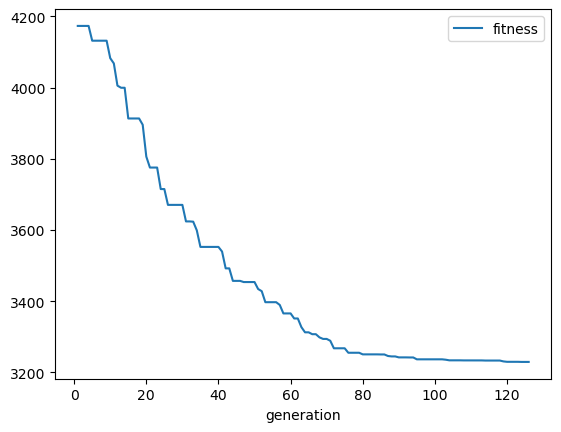

In [25]:
trained_df[["fitness", "generation"]].groupby("generation").min().plot()

TODO: Check why there are increase in fitness

## Check if individuals are similar

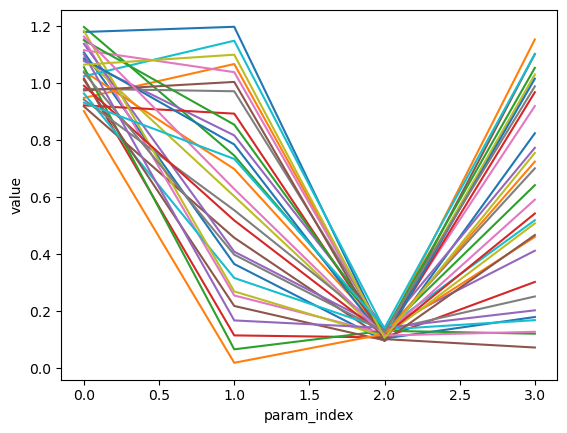

In [11]:
for i in range(30):
    sns.lineplot(
        data=trained_df[
            (trained_df["param_type"] == "mu")
            & (trained_df["generation"] == 1)
            & (trained_df["individual"] == 100 * i)
        ],
        x="param_index",
        y="value",
    )

TODO: Check why initialization do not seem so random? It seems that each parameter has its own distribution

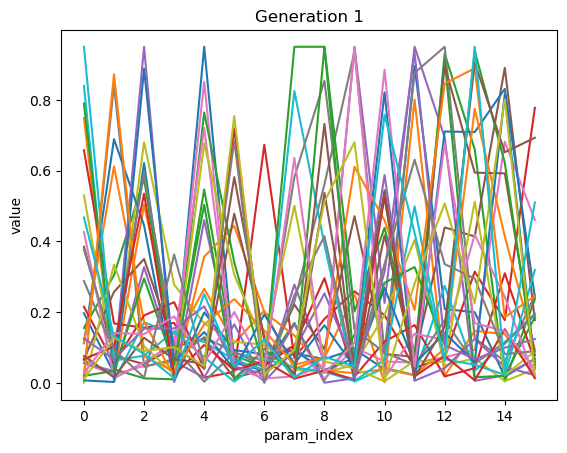

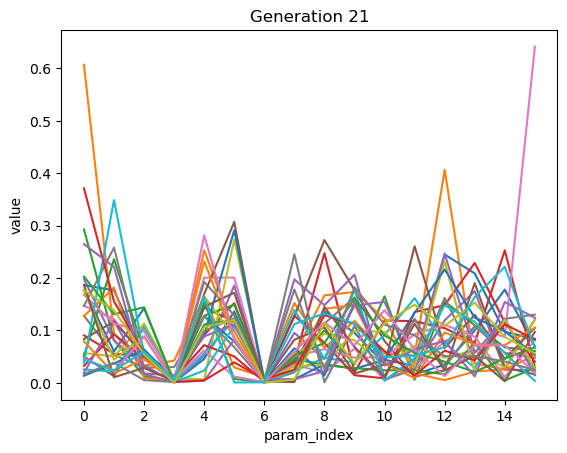

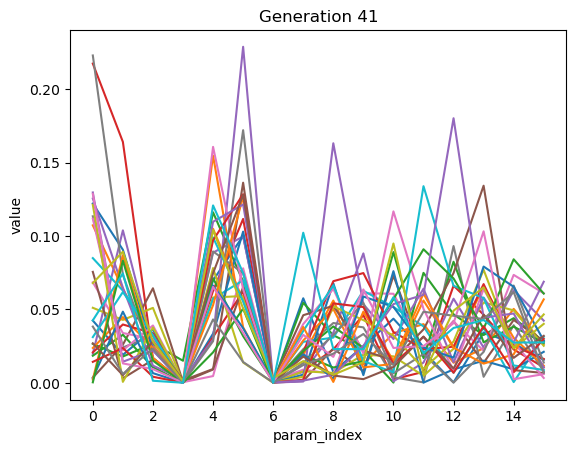

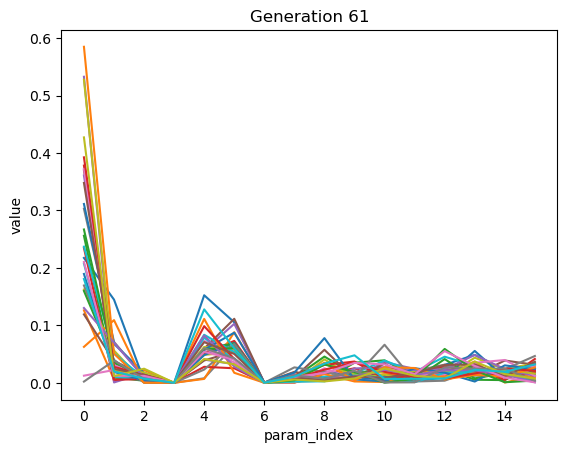

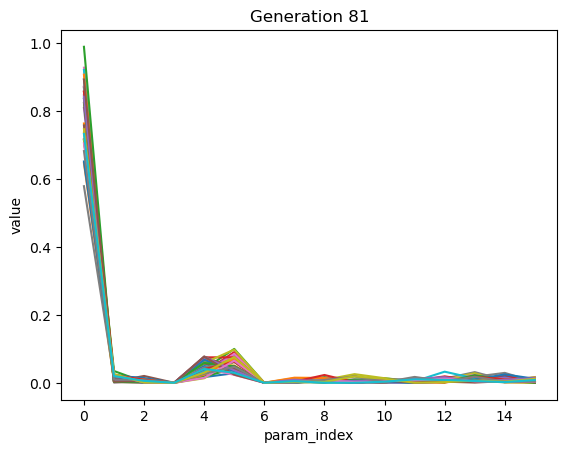

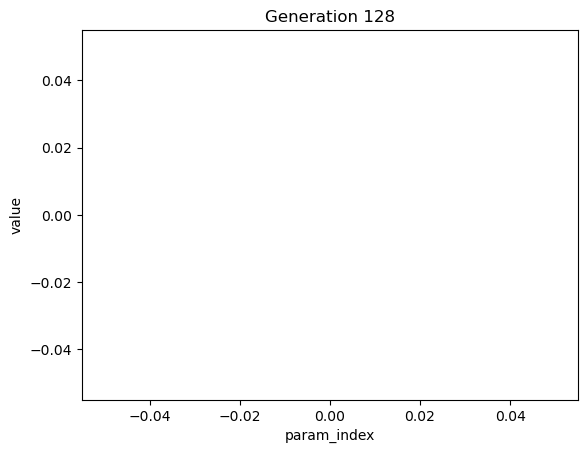

In [26]:
for gen in list(range(1, 100, 20)) + [128]:
    for i in range(30):

        sns.lineplot(
            data=trained_df[
                (trained_df["param_type"] == "rho")
                & (trained_df["generation"] == gen)
                & (trained_df["individual"] == i)
            ],
            x="param_index",
            y="value",
        )
    # plt.ylim(0, 1)
    plt.title(f"Generation {gen}")
    plt.show()

<Axes: xlabel='param_index', ylabel='value'>

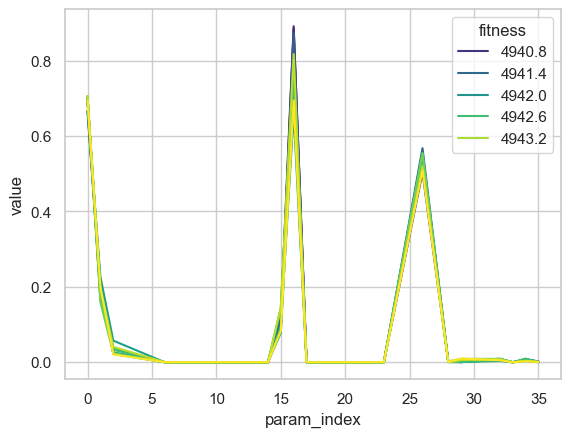

In [35]:
data_subset = trained_df[
    (trained_df["param_type"] == "rho") & (trained_df["generation"] == 140)
]

# Create the lineplot with 'individual' as the hue
sns.lineplot(
    data=data_subset,
    x="param_index",
    y="value",
    hue="fitness",  # Use 'fitness' to color the lines
    palette="viridis",  # Choose a suitable color palette
)

0.7587060725360062


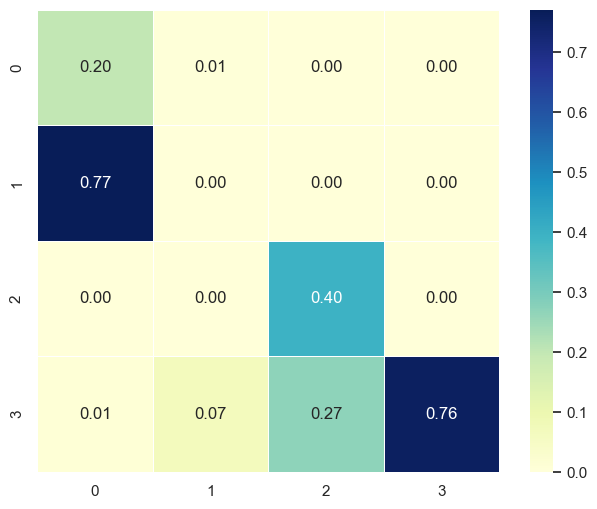

In [20]:
# Filter rows that start with 'rho_'
data_subset = trained_df[
    (trained_df["param_type"] == "rho")
    & (trained_df["generation"] == 127)
    & (trained_df["individual"] == 0)
]

# Create an empty 6x6 matrix of zeros
matrix = np.zeros((N_EVENT_TYPES, N_EVENT_TYPES))

# Iterate through each row in the filtered DataFrame
for _, row in data_subset.iterrows():
    # Extract the index (number after 'rho_')
    param_name = row["param"]
    index = int(param_name.split("_")[1]) - 1  # Convert to 0-based index

    # Find the corresponding row and column in the 6x6 matrix
    matrix_row = index // N_EVENT_TYPES  # Row index in the 6x6 matrix
    matrix_col = index % N_EVENT_TYPES  # Column index in the 6x6 matrix

    # Assign the value from the DataFrame to the corresponding matrix position
    matrix[matrix_row, matrix_col] = row["value"]

# Create the heatmap using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix, annot=True, cmap="YlGnBu", cbar=True, square=True, fmt=".2f", linewidths=0.5
)
print(np.max(np.linalg.eigvals(matrix)))

<Axes: xlabel='param_index', ylabel='value'>

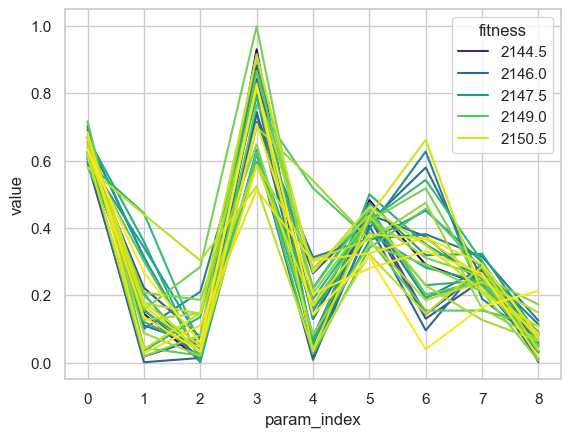

In [134]:
data_subset = trained_df[
    (trained_df["param_type"] == "alpha") & (trained_df["generation"] == 200)
]

# Create the lineplot with 'individual' as the hue
sns.lineplot(
    data=data_subset,
    x="param_index",
    y="value",
    hue="fitness",  # Use 'fitness' to color the lines
    palette="viridis",  # Choose a suitable color palette
)

TODO: why the worst is not discarded?

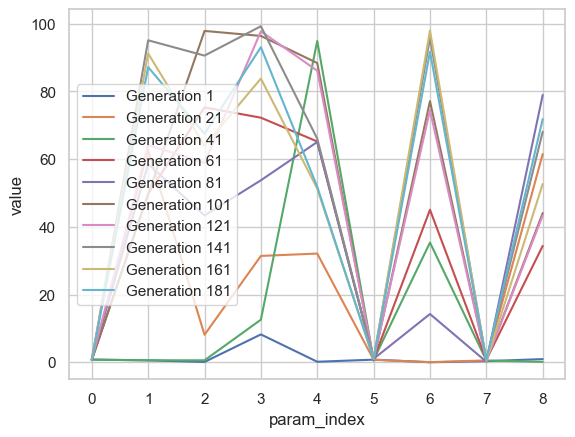

In [137]:
# get the individual with the best fitness for each generation (not the index) but the individual number
# Create a DataFrame with the individual with lowest fitness for each generation
best_individuals = trained_df.loc[trained_df.groupby("generation")["fitness"].idxmin()][
    ["generation", "individual"]
]
best_individuals = best_individuals.merge(trained_df, on=["generation", "individual"])

# Create the lineplot with 'individual' as the hue
for gen in range(1, 201, 20):
    sns.lineplot(
        data=best_individuals[
            (best_individuals["param_type"] == "beta")
            & (best_individuals["generation"] == gen)
        ],
        x="param_index",
        y="value",
        label=f"Generation {gen}",
    )

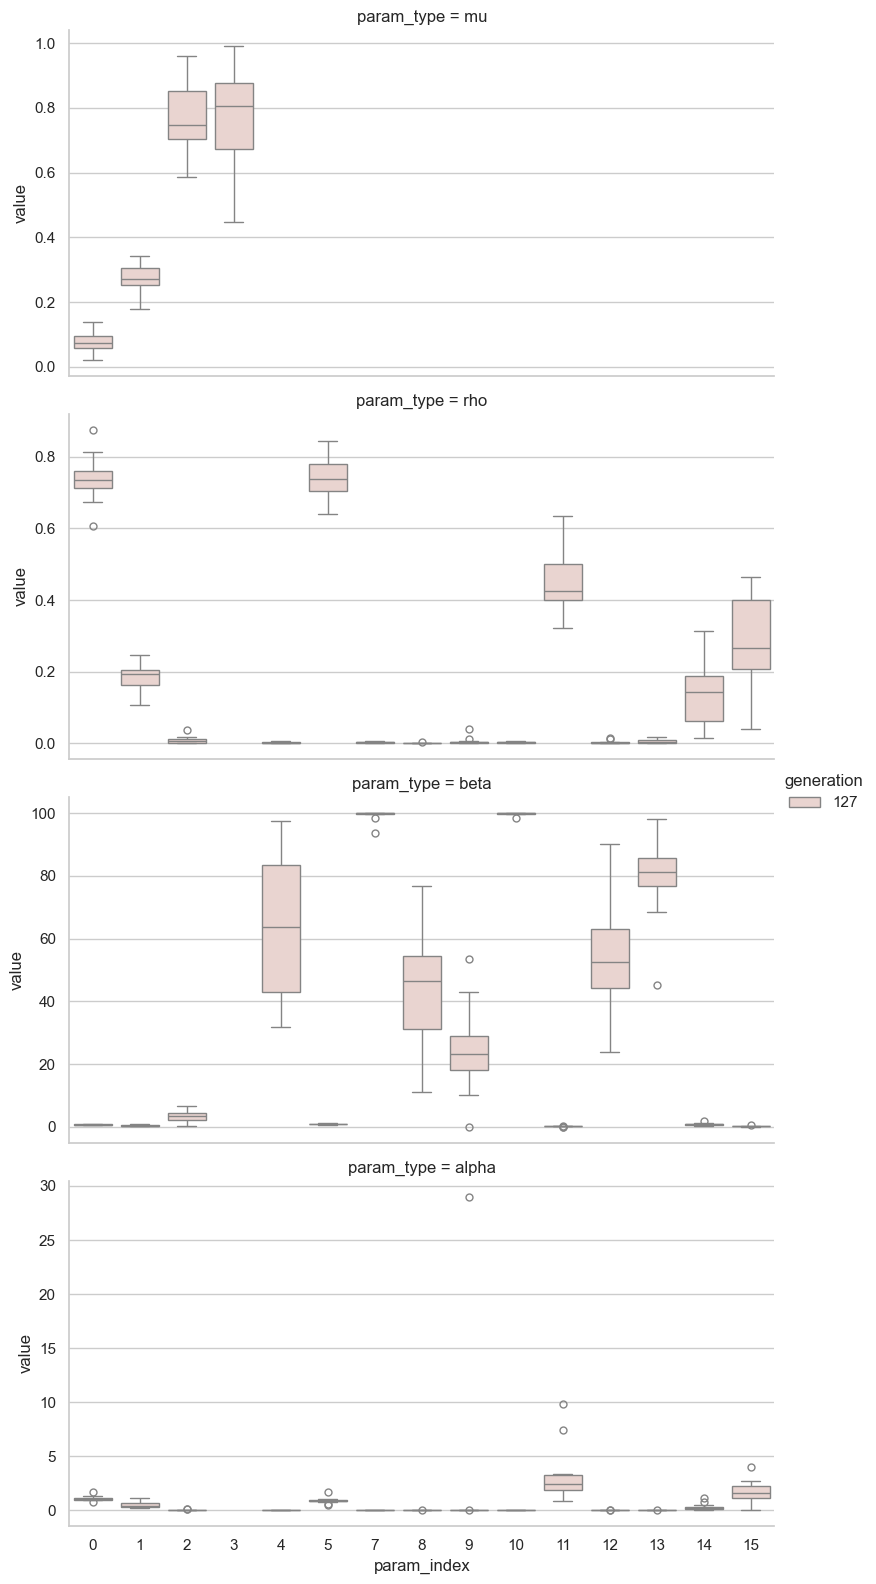

In [14]:
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=trained_df[(trained_df["generation"].isin([127]))],
    x="param_index",
    y="value",
    hue="generation",
    col=None,  # No columns
    row="param_type",  # Facet by the "param" variable (1 column, 3 rows)
    kind="box",  # Boxplot
    height=4,  # Height of each facet
    aspect=2,  # Aspect ratio of each facet
    sharey=False,  # Share the y-axis between facets
    # showfliers=False,  # Do not show outliers
)

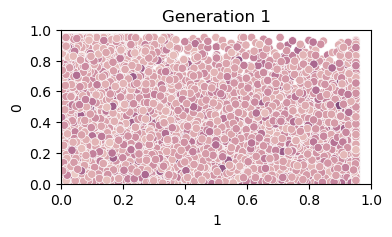

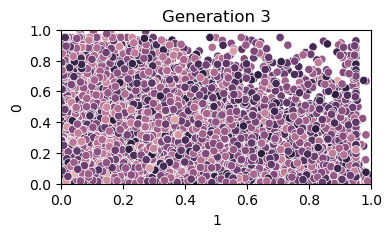

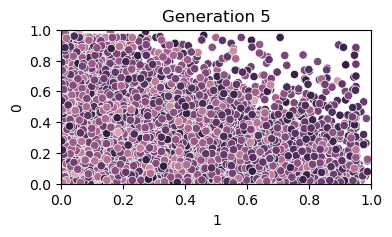

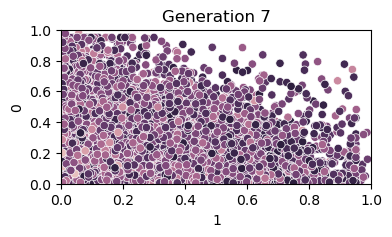

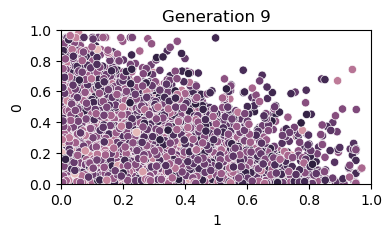

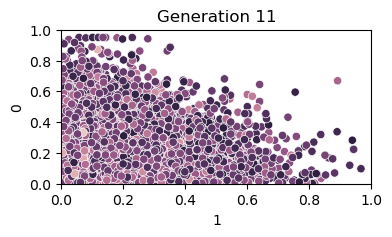

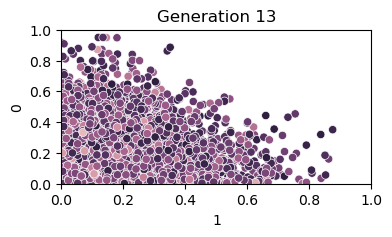

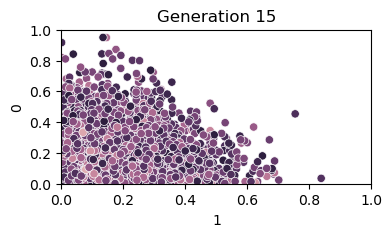

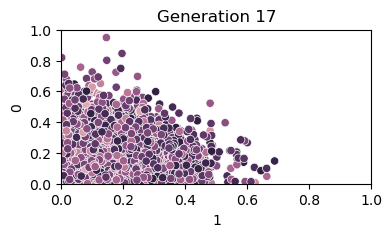

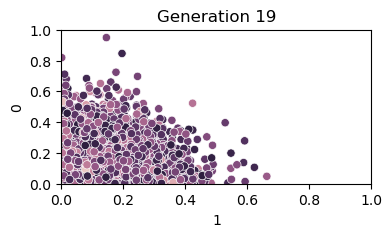

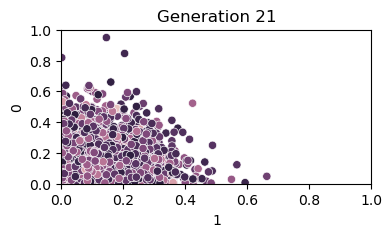

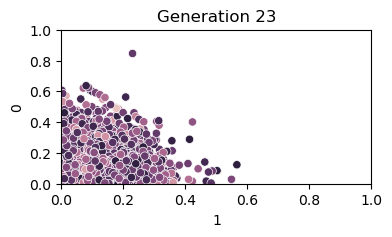

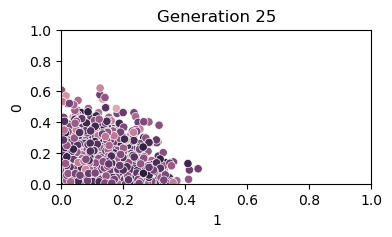

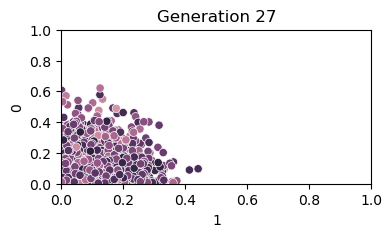

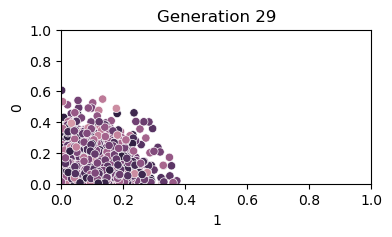

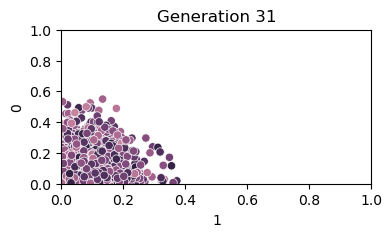

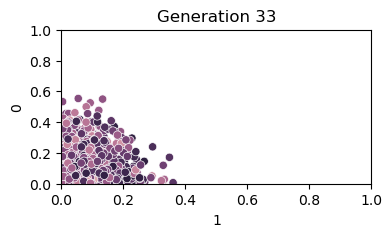

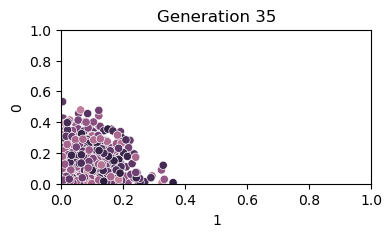

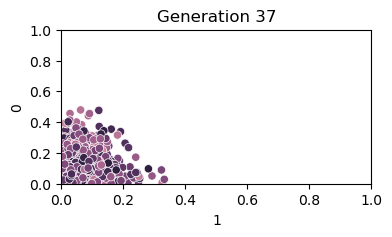

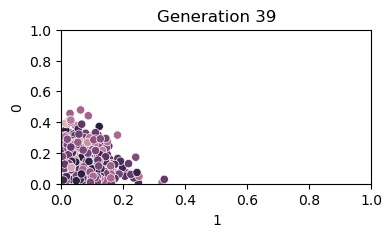

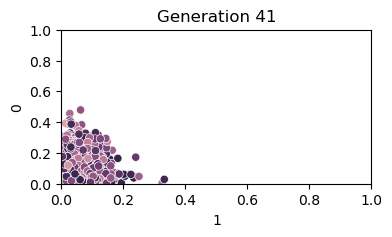

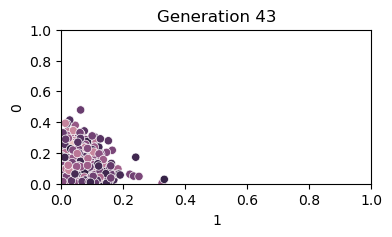

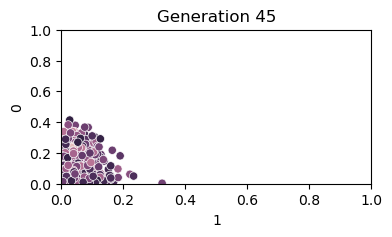

In [23]:
# scatterplot for generation 1 where x is alpha_0 and y is alpha_1
col1 = 1
col2 = 0
for gen_number in range(1, 47, 2):
    df = trained_df[
        (trained_df["generation"] == gen_number)
        & (trained_df["param_type"] == "rho")
        & (trained_df["param_index"].isin([col1, col2]))
    ]
    df = df.pivot(index="individual", columns="param_index", values="value")
    df = df.reset_index()
    df = df.merge(
        trained_df[trained_df["generation"] == gen_number][
            ["individual", "fitness"]
        ].drop_duplicates(),
        on="individual",
    )

    plt.figure(figsize=(4, 2))
    sns.scatterplot(data=df, x=col1, y=col2, hue="fitness")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.title(f"Generation {gen_number}")
    plt.legend().remove()
    plt.show()

(array([ 3.,  5.,  5.,  6., 12., 10., 17., 30., 35., 41., 56., 49., 53.,
        63., 68., 86., 94., 69., 51., 39., 39., 37., 35., 32., 17., 13.,
        14., 12.,  4.,  5.]),
 array([0.1846673 , 0.21059633, 0.23652536, 0.2624544 , 0.28838343,
        0.31431246, 0.34024149, 0.36617052, 0.39209955, 0.41802859,
        0.44395762, 0.46988665, 0.49581568, 0.52174471, 0.54767375,
        0.57360278, 0.59953181, 0.62546084, 0.65138987, 0.6773189 ,
        0.70324794, 0.72917697, 0.755106  , 0.78103503, 0.80696406,
        0.8328931 , 0.85882213, 0.88475116, 0.91068019, 0.93660922,
        0.96253825]),
 <BarContainer object of 30 artists>)

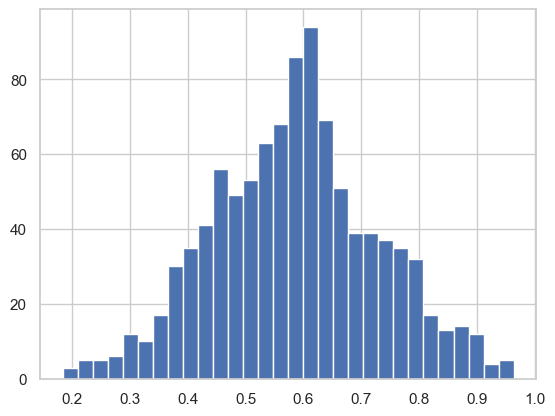

In [19]:
def generate_normalized_matrices(num_matrices, shape, seed=None):
    if seed is not None:
        np.random.seed(seed)  # Set seed for reproducibility

    matrices = []
    for _ in range(num_matrices):
        matrix = np.random.randn(
            *shape
        )  # Generate a random matrix (Gaussian distribution)
        norm = np.sqrt(np.sum(matrix**2))  # Compute sum of squares and take sqrt
        matrix /= norm  # Normalize
        matrices.append(matrix)

    return np.array(matrices)


# Example usage
num_matrices = 1000
shape = (3, 3)  # Example 3x3 matrices

matrices = generate_normalized_matrices(num_matrices, shape)

# Compute the spectral radii of the matrices
spectral_radii = [np.max(np.abs(np.linalg.eigvals(matrix))) for matrix in matrices]

# Plot the histogram of spectral radii
plt.hist(spectral_radii, bins=30)

## Punti da vedere

1. Errore fitness increase
2. Vedere perchè più scarso non è scartato

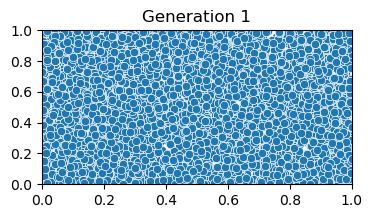

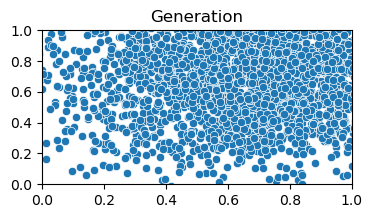

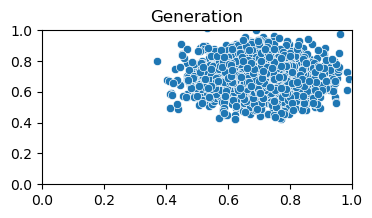

In [42]:
m = np.random.uniform(0, 1, (5000, 2))

# do scatterplot of m
# change figsize to make the plot smaller
plt.figure(figsize=(4, 2))
sns.scatterplot(x=m[:, 0], y=m[:, 1])
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("Generation 1")
plt.show()

for std in [0.3, 0.1]:
    m = np.random.normal(0.7, std, (int(5000 * (std + 0.3)), 2))

    # do scatterplot of m
    plt.figure(figsize=(4, 2))
    sns.scatterplot(x=m[:, 0], y=m[:, 1])
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.title(f"Generation")
    plt.show()

In [ ]:
from optimization.lshade import (
    get_initial_random_population_my,
    get_initial_random_population,
)



mu_lower_bound = 0.0


mu_upper_bound = 1.2


rho_lower_bound = 0.0


rho_upper_bound = 0.9


beta_lower_bound = 0.0


beta_upper_bound = 100.0



n = 6


size = 30_000


seed = 42


events_type_count = [3764, 3433, 2389, 2325, 1975, 1721]


population = get_initial_random_population(
    np.concatenate(
        (
            mu_upper_bound * np.ones(n),

            rho_upper_bound * np.ones(n * n),
            beta_upper_bound * np.ones(n * n),
        )
    ),

    size,
    events_type_count,

    3300,
    np.full(n + 2 * n * n, np.nan),
)


my_population = get_initial_random_population_my(
    np.concatenate(
        (
            mu_upper_bound * np.ones(n),
            rho_upper_bound * np.ones(n * n),
            beta_upper_bound * np.ones(n * n),
        )
    ),
    size,
    events_type_count,
    3300,
    np.full(n + 2 * n * n, np.nan),
)

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000


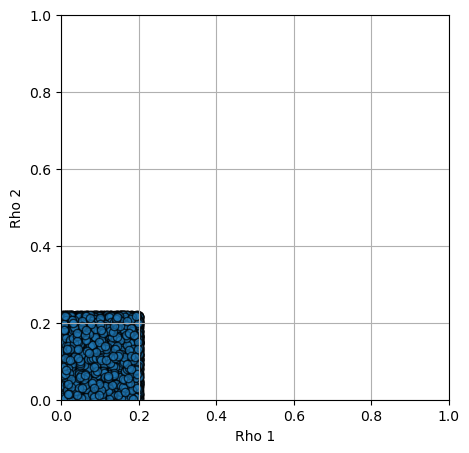

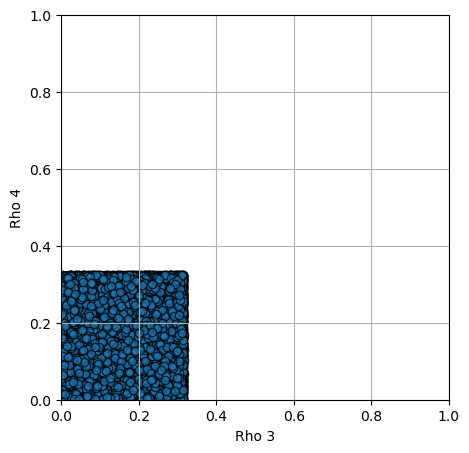

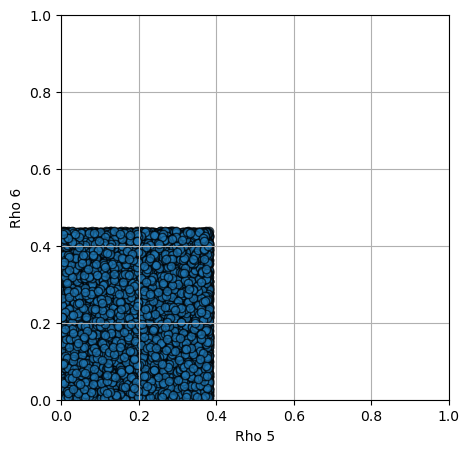

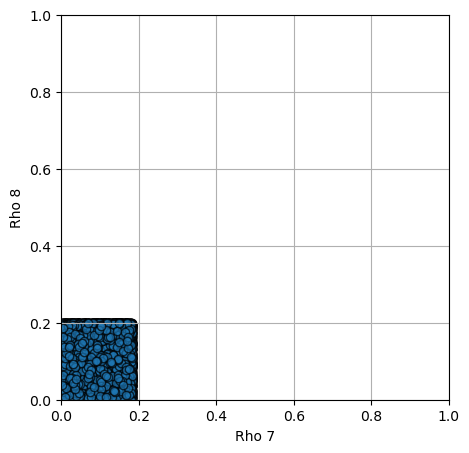

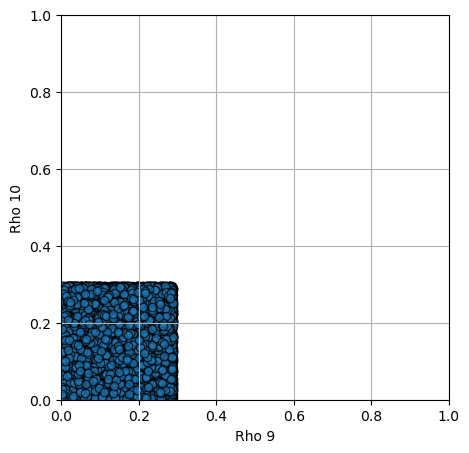

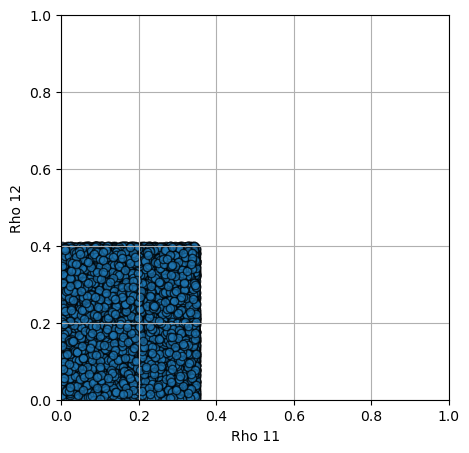

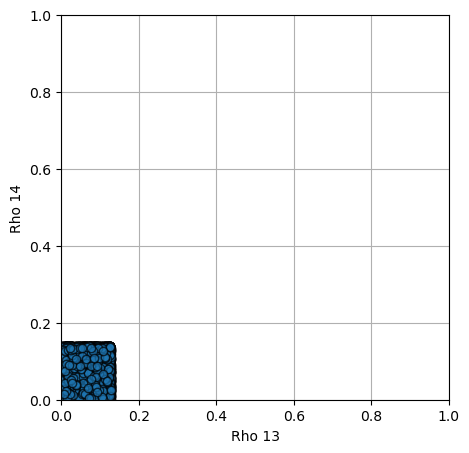

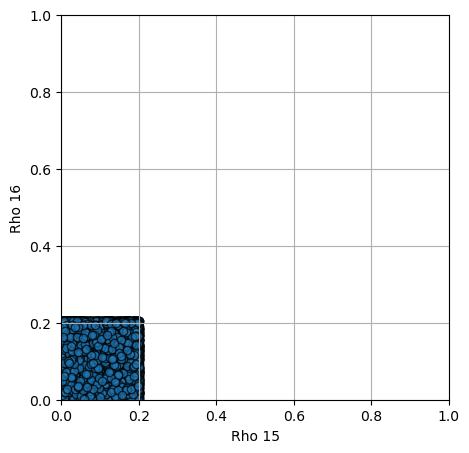

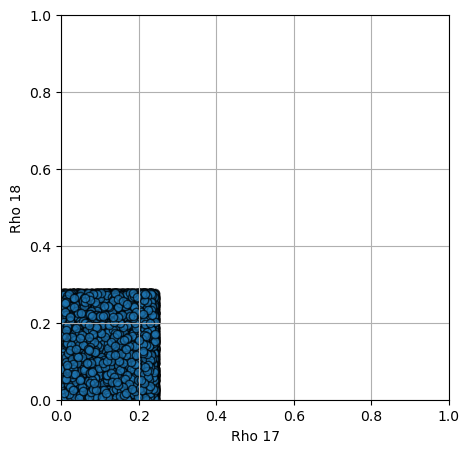

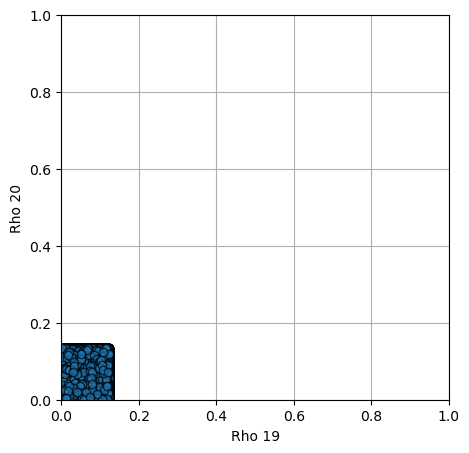

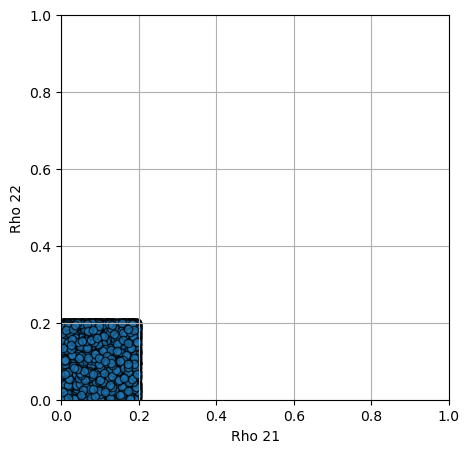

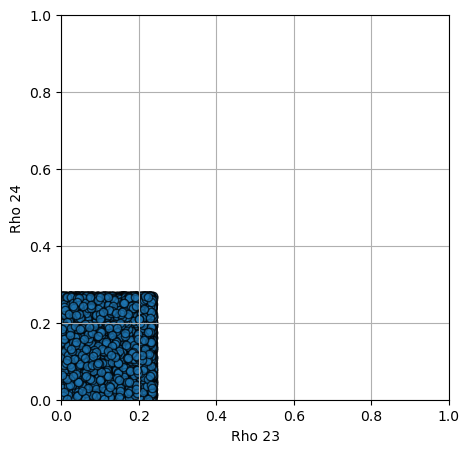

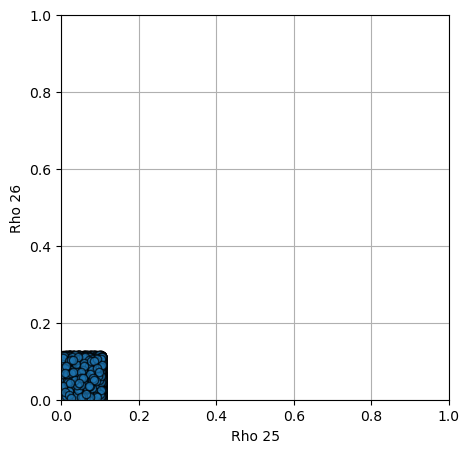

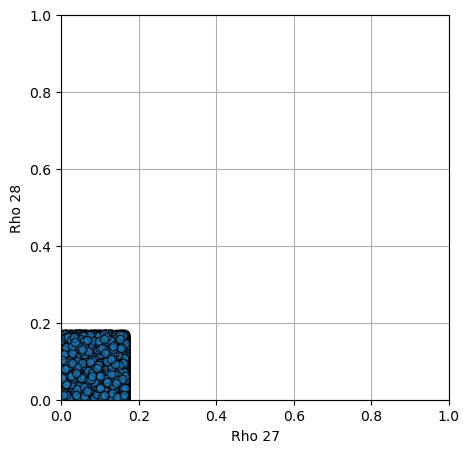

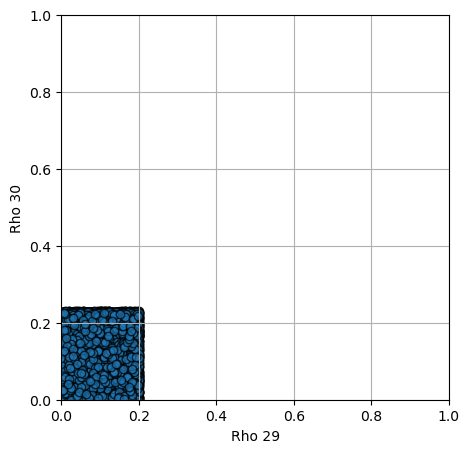

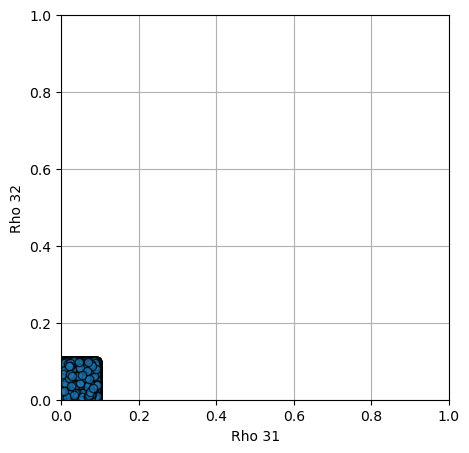

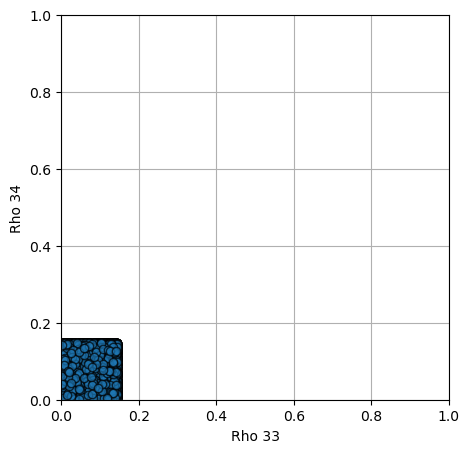

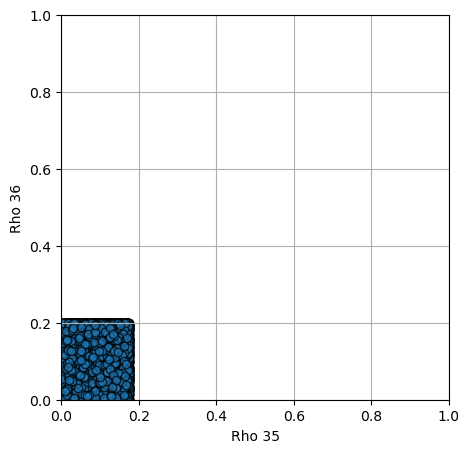

In [4]:
for i in range(0, 36 - 1, 2):  # Step of 2 to get pairs
    plt.figure(figsize=(5, 5))
    plt.scatter(
        population[:, 6 + i], population[:, 6 + i + 1], alpha=0.7, edgecolors="k"
    )
    plt.xlabel(f"Rho {i+1}")
    plt.ylabel(f"Rho {i+2}")
    plt.grid(True)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.show()

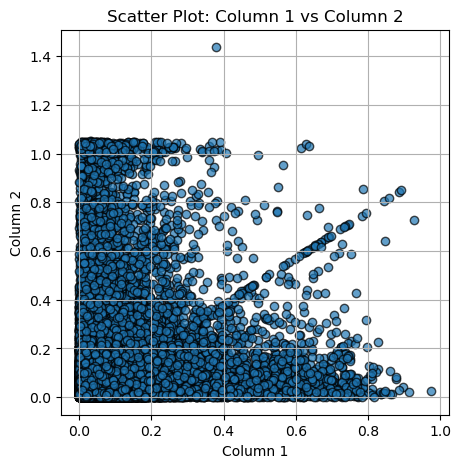

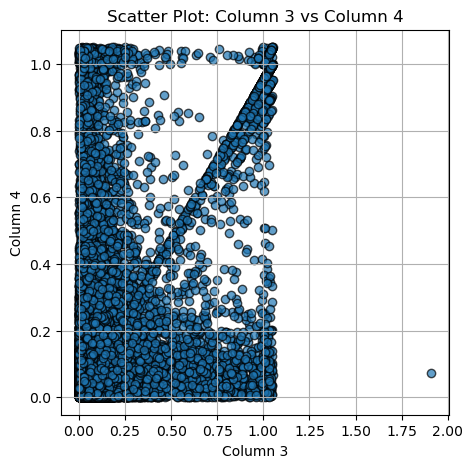

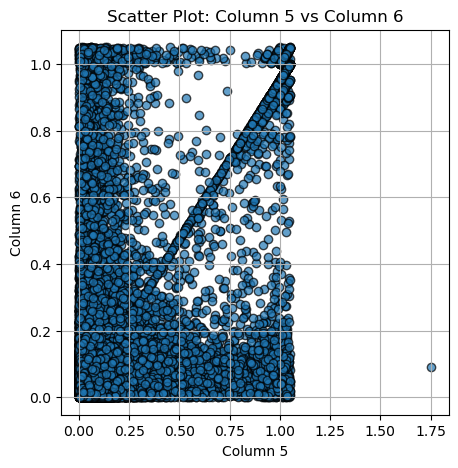

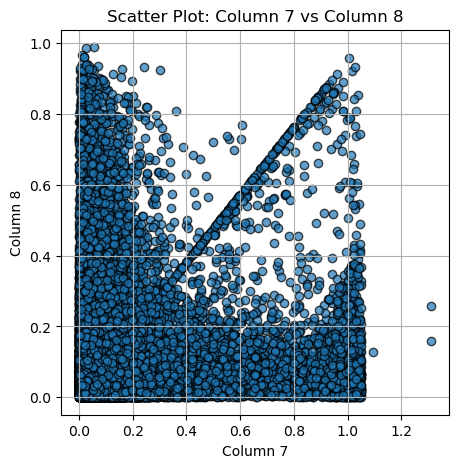

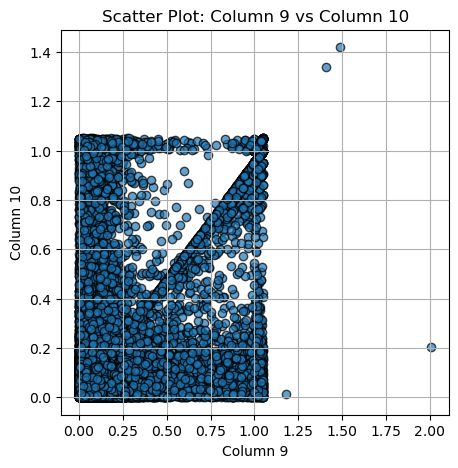

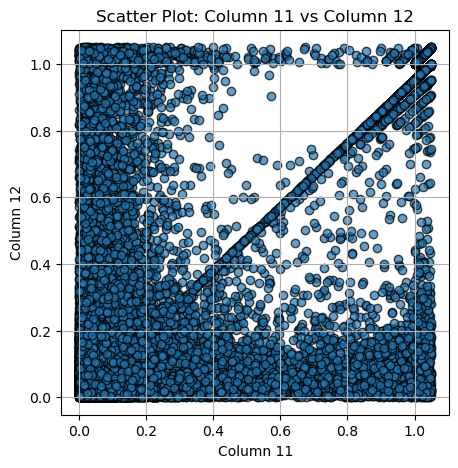

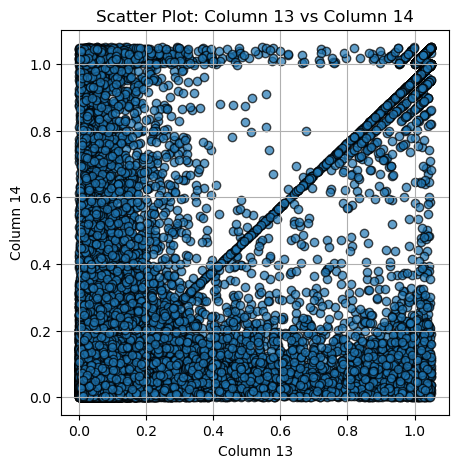

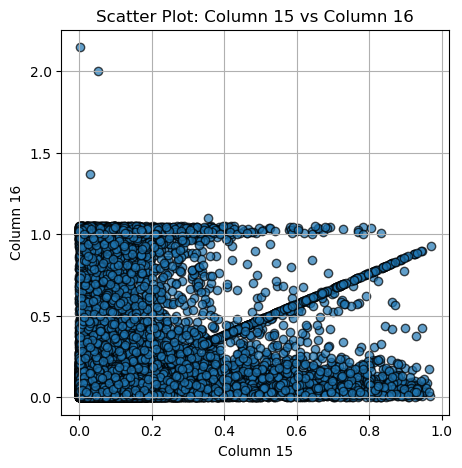

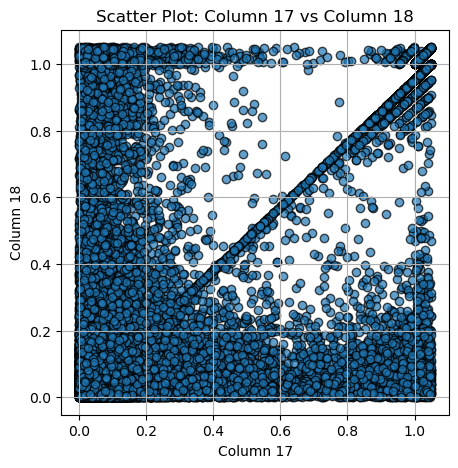

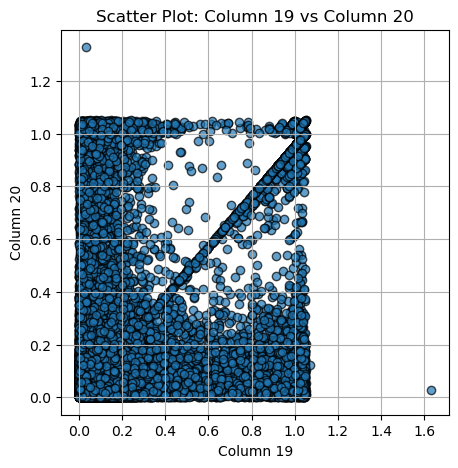

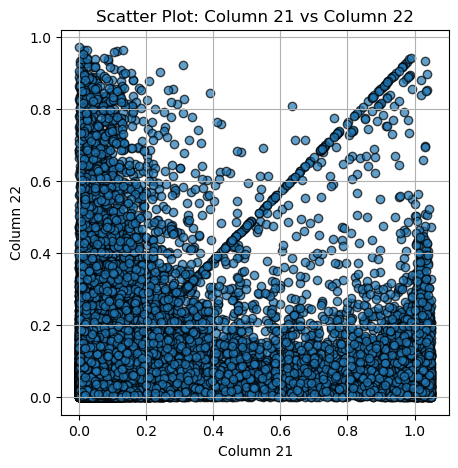

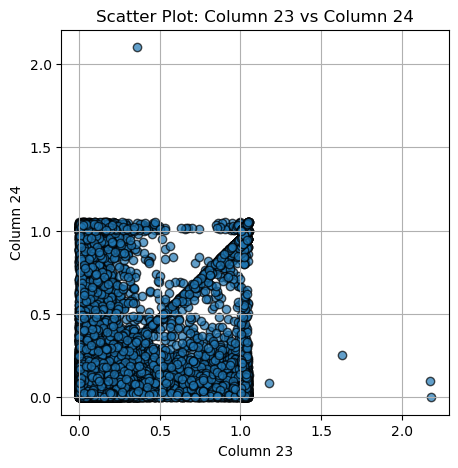

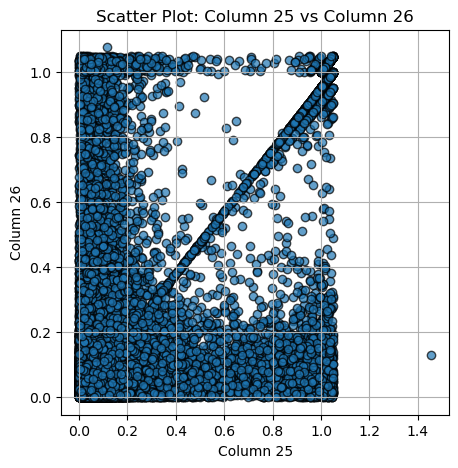

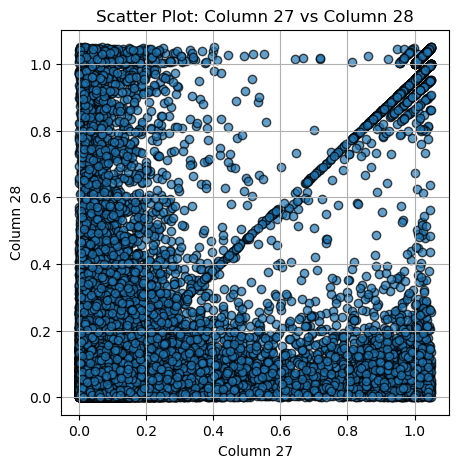

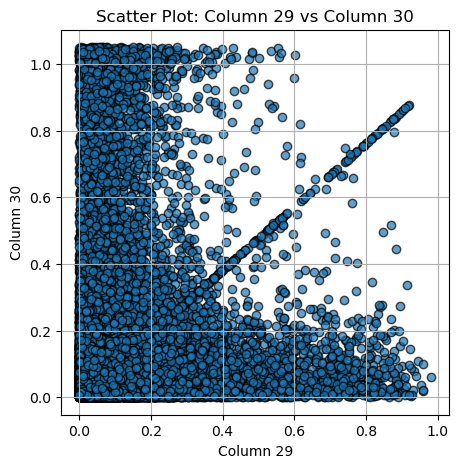

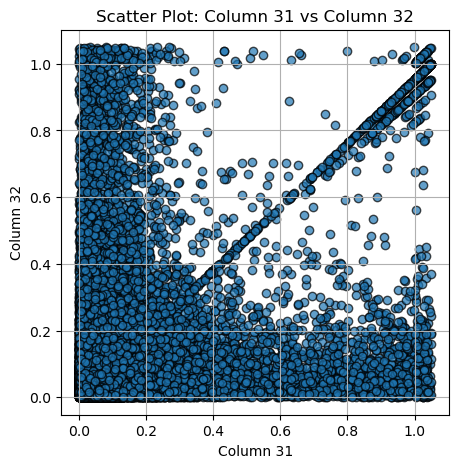

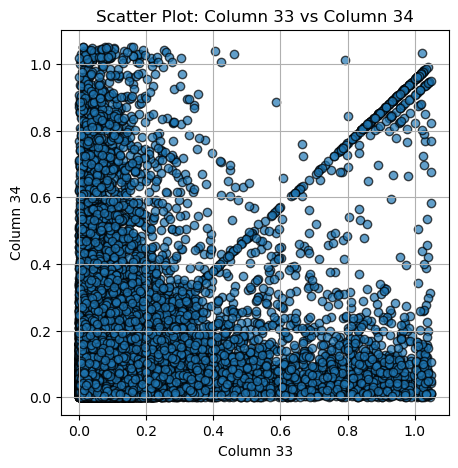

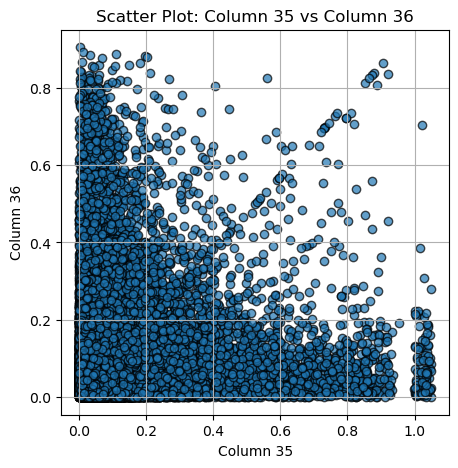

In [6]:
for i in range(0, 36 - 1, 2):  # Step of 2 to get pairs
    plt.figure(figsize=(5, 5))
    plt.scatter(
        my_population[:, 6 + i], my_population[:, 6 + i + 1], alpha=0.7, edgecolors="k"
    )
    plt.xlabel(f"Column {i+1}")
    plt.ylabel(f"Column {i+2}")
    plt.title(f"Scatter Plot: Column {i+1} vs Column {i+2}")
    plt.grid(True)
    plt.show()

<Axes: ylabel='Count'>

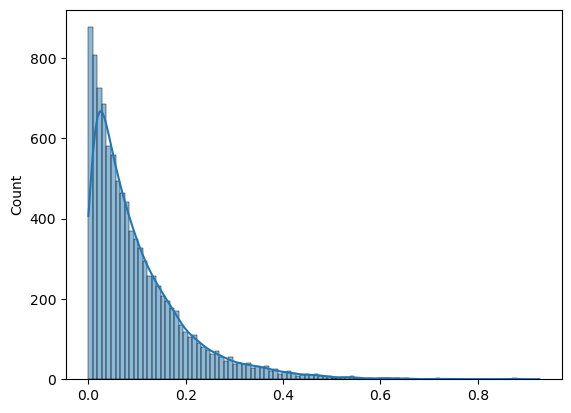

In [9]:
samples = np.random.exponential(scale=0.1, size=10000)  # 10 samples
sns.histplot(samples, bins=100, kde=True)